In [26]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# Research questions

- <mark>Can we identify distinct groups of artists who are enjoyed by similar listeners?</mark>

- Can we predict which songs a user is likely to add to their genre based on their listening history and similar users’ behavior?
  - Engineered fields: Song popularity (Number of times a song appears across all playlists) and Collaborative similarity index (Overlap in playlist content between users)
- Can we predict whether a song will be added to a playlist , based on the song elements (key, tempo, genre, and loudness) of the songs that already exist in the playlist?

In [22]:
df = pd.read_csv('../../data/clean_data.csv')
df.head()

,user,artist,playlist,tracks,spotify_popularity,genre,key,tempo,popularity,energy,...,good_for_work_study,good_for_relaxation_meditation,good_for_exercise,good_for_running,good_for_yoga_stretching,good_for_driving,good_for_social_gatherings,good_for_morning_routine,length_seconds,loudness_db_num
0,00055176fea33f6e027cd3302289378b,5 Seconds Of Summer,favs,10,0.025129,"pop,pop rock,pop punk",D Maj,134.162338,44.811688,80.545455,...,0.000000,0.000000,0.285714,0.162338,0.0,0.038961,0.006494,0.032468,210.675325,-4.913896
1,00055176fea33f6e027cd3302289378b,Against The Current,favs,3,0.001571,"acoustic,pop rock,rock",G Maj,121.264706,37.147059,84.441176,...,0.000000,0.000000,0.352941,0.088235,0.0,0.029412,0.000000,0.029412,199.794118,-4.070000
2,00055176fea33f6e027cd3302289378b,All Time Low,favs,8,0.030531,"alternative rock,emo,pop punk",D Maj,142.752066,38.801653,87.652893,...,0.008264,0.000000,0.206612,0.049587,0.0,0.000000,0.000000,0.000000,202.413223,-4.211901
3,00055176fea33f6e027cd3302289378b,Austin Mahone,favs,1,0.016145,pop,B Maj,111.692308,31.871795,63.461538,...,0.076923,0.051282,0.230769,0.025641,0.0,0.128205,0.000000,0.230769,198.230769,-5.960256
4,00055176fea33f6e027cd3302289378b,Avril Lavigne,favs,2,0.071806,"rock,pop,alternative rock",F Maj,128.726316,57.505263,79.252632,...,0.005263,0.000000,0.242105,0.152632,0.0,0.005263,0.010526,0.021053,214.731579,-4.756263


# Preprocessing

Let's cluster this data to find similar groups

In [23]:
# separate columns by dtypes
cat_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Categorical columns: ', cat_cols)
print('Numerical columns: ', num_cols)
df.isnull().sum().sum()

Categorical columns:  ['user', 'artist', 'playlist', 'genre', 'key']
Numerical columns:  ['tracks', 'spotify_popularity', 'tempo', 'popularity', 'energy', 'danceability', 'positiveness', 'speechiness', 'liveness', 'acousticness', 'instrumentalness', 'good_for_party', 'good_for_work_study', 'good_for_relaxation_meditation', 'good_for_exercise', 'good_for_running', 'good_for_yoga_stretching', 'good_for_driving', 'good_for_social_gatherings', 'good_for_morning_routine', 'length_seconds', 'loudness_db_num']


0

In [24]:
# run tf_idf for clustering (exclude id columns like user/artist)
tf_idf_cols = ['playlist', 'genre', 'key']

# create vectorizers
playlist_vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
playlist_tfidf = playlist_vectorizer.fit_transform(df['playlist'])

genre_vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
genre_tfidf = genre_vectorizer.fit_transform(df['genre'])

key_vectorizer = TfidfVectorizer(
    max_df=0.5,
    min_df=5,
    stop_words="english",
)
key_tfidf = key_vectorizer.fit_transform(df['key'])

In [33]:
# use kmeans to cluster professions together
# tweaked n_clusters using elbow method below
playlist_kmeans = KMeans(n_clusters=35, random_state=42)
# fit the model
playlist_kmeans.fit(playlist_tfidf)
# store cluster labels in a variable
playlist_clusters = playlist_kmeans.labels_
df['playlist_cluster'] = playlist_clusters
df_playlist_cluster = df[['playlist', 'playlist_cluster']].drop_duplicates().copy()
# look at this to see if it makes sense
df_playlist_cluster

/Users/brandon/miniforge3/envs/mlenv_now/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,playlist,playlist_cluster
0,favs,6
41,Fav songs,7
49,Sad songs,7
51,2014,29
83,Agnetha Fältskog,6
...,...,...
3026574,l a d y anthems,6
3026588,KickAss,6
3026645,natural elements,6
3026648,5:19,6


# Playlist clustering notes
## k=35

- 0: baby
- 1: starred
- 2: free
- 3: radio
- 4: 80's
- 5: good, covers, others (this may be misc)
- 6: misc
- 7: songs
- 8: list
- 9: rock
- 10: day
- 11: library
- 12: time
- 13: playlist
- 14: work
- 15: party
- 16: country & summer
- 17: pop
- 18: new
- 19: 2012
- 20: live
- 21: hip
- 22: various artists
- 23: music
- 24: warm
- 25: deluxe
- 26: 2015
- 27: favorites
- 28: dance
- 29: 2014
- 30: smooth
- 31: hits
- 32: stuff
- 33: 2013
- 34: hip hop

In [35]:
df_playlist_cluster['playlist_cluster'].value_counts()

6     105995
22      2375
25      1424
7       1419
23      1409
20      1286
13      1251
29      1220
9       1184
33      1081
18       934
19       852
16       767
17       745
26       677
28       652
12       598
10       573
5        563
15       553
31       503
34       438
32       394
8        392
14       231
0        223
4        212
27       211
2        115
30        76
11        44
3         37
24        35
21        29
1         10
Name: playlist_cluster, dtype: int64

In [39]:
# commenting out due to large runtime; cluster analysis recorded in notes
# # optimize clustering - playlist
# # find optimal k to use for grouping (hopefully get that 0 cluster down)
# inertia = []

# # we'll go up to 20 clusters
# upper = 40

# # loop through, try every k value from 2-20
# for k in range(2, upper):
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     kmeans.fit(playlist_tfidf)
#     inertia.append(kmeans.inertia_)

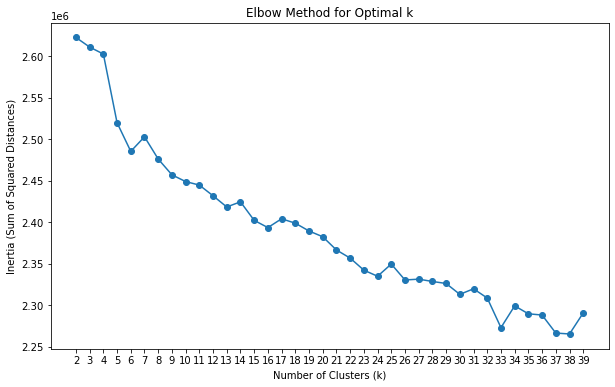

In [30]:
# # elbow method to find optimal k
# fig = plt.figure(figsize=(10, 6)) 
# plt.plot(range(2, upper), inertia, marker='o')
# plt.title('Elbow Method for Optimal k')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (Sum of Squared Distances)')
# plt.xticks(range(2, upper))
# plt.show()

In [18]:
df.head()

,user,artist,playlist,tracks,spotify_popularity,genre,key,tempo,popularity,energy,...,good_for_work_study,good_for_relaxation_meditation,good_for_exercise,good_for_running,good_for_yoga_stretching,good_for_driving,good_for_social_gatherings,good_for_morning_routine,length_seconds,loudness_db_num
0,00055176fea33f6e027cd3302289378b,5 Seconds Of Summer,0.0,10,0.025129,0.0,1.0,134.162338,44.811688,80.545455,...,0.000000,0.000000,0.285714,0.162338,0.0,0.038961,0.006494,0.032468,210.675325,-4.913896
1,00055176fea33f6e027cd3302289378b,Against The Current,1.0,3,0.001571,0.0,0.0,121.264706,37.147059,84.441176,...,0.000000,0.000000,0.352941,0.088235,0.0,0.029412,0.000000,0.029412,199.794118,-4.070000
2,00055176fea33f6e027cd3302289378b,All Time Low,0.0,8,0.030531,1.0,0.0,142.752066,38.801653,87.652893,...,0.008264,0.000000,0.206612,0.049587,0.0,0.000000,0.000000,0.000000,202.413223,-4.211901
3,00055176fea33f6e027cd3302289378b,Austin Mahone,NaN,1,0.016145,NaN,NaN,111.692308,31.871795,63.461538,...,0.076923,0.051282,0.230769,0.025641,0.0,0.128205,0.000000,0.230769,198.230769,-5.960256
4,00055176fea33f6e027cd3302289378b,Avril Lavigne,NaN,2,0.071806,NaN,NaN,128.726316,57.505263,79.252632,...,0.005263,0.000000,0.242105,0.152632,0.0,0.005263,0.010526,0.021053,214.731579,-4.756263


In [40]:
# make sure you didn't do anything wrong
df.isnull().sum().sum()

0

In [46]:
# use kmeans to cluster genres together
genre_k = 12
# tweaked n_clusters using elbow method below
genre_kmeans = KMeans(n_clusters=genre_k, random_state=42)
# fit the model
genre_kmeans.fit(genre_tfidf)
# store cluster labels in a variable
genre_clusters = genre_kmeans.labels_
df['genre_cluster'] = genre_clusters
df_genre_cluster = df[['genre', 'genre_cluster']].drop_duplicates().copy()
# look at this to see if it makes sense
df_genre_cluster

/Users/brandon/miniforge3/envs/mlenv_now/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


,genre,genre_cluster
0,"pop,pop rock,pop punk",5
1,"acoustic,pop rock,rock",0
2,"alternative rock,emo,pop punk",9
3,pop,5
4,"rock,pop,alternative rock",0
...,...,...
2919402,"progressive rock,metal,progressive metal",9
2931633,"j-pop,indie,pop",8
2960338,"punk,pop rock",5
2973903,"rock,hip-hop,reggae",1


# Genre clustering notes

## k = 12

- 0: rock
- 1: hip-hop
- 2: electronic
- 3: country
- 4: soul
- 5: pop
- 6: synth
- 7: folk
- 8: indie
- 9: misc / rock / metal / punk
- 10: electropop
- 11: jazz

In [47]:
df_genre_cluster['genre_cluster'].value_counts()

9     967
0     359
2     240
8     215
11    129
7     119
4     115
1     101
5      91
6      82
10     81
3      80
Name: genre_cluster, dtype: int64

In [ ]:
# # commenting out due to large runtime; cluster analysis recorded in notes
# # optimize clustering - playlist
# # find optimal k to use for grouping (hopefully get that 0 cluster down)
# inertia = []

# # we'll go up to 20 clusters
# upper = 20

# # loop through, try every k value from 2-20
# for k in range(2, upper):
#     kmeans = KMeans(n_clusters=k, random_state=0)
#     kmeans.fit(genre_tfidf)
#     inertia.append(kmeans.inertia_)

/Users/brandon/miniforge3/envs/mlenv_now/lib/python3.8/site-packages/sklearn/cluster/_kmeans.py:1416: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=10)


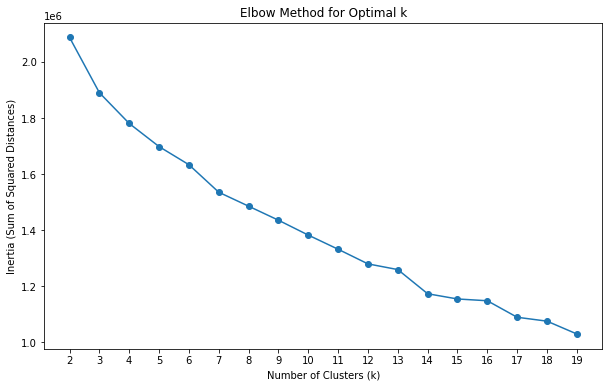

In [ ]:
# # elbow method to find optimal k
# fig = plt.figure(figsize=(10, 6)) 
# plt.plot(range(2, upper), inertia, marker='o')
# plt.title('Elbow Method for Optimal k')
# plt.xlabel('Number of Clusters (k)')
# plt.ylabel('Inertia (Sum of Squared Distances)')
# plt.xticks(range(2, upper))
# plt.show()